In [101]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import os

In [235]:
%matplotlib tk
plt.style.use('~/.config/matplotlib/matplotlibrc')
L_view = 512
fill_view = 0.5
lw=2
ls_s = ["-", "--"]
unique_adiabatic_times = []
xlim_rights = [25,50,60,100,150,300,900,1000]

data_to_plot = {}
for file_name in os.listdir("../data/rodeo/"):
    if f"L{L_view}" in file_name and f"fill{str(fill_view).replace('.', 'p')}" in file_name:
        data = np.load("../data/rodeo/" + file_name, allow_pickle=True)
        print(data.files)
        if data['adiabatic_time'] == 0:
            continue
        try:
            data_to_plot[int(data['time_cut'])].append((data['rodeo_total_times'], data['fidelities'], data['gap'], data['adiabatic_time'], data["success_probs"]))
        except:
            data_to_plot[int(data['time_cut'])] = [(data['rodeo_total_times'], data['fidelities'], data['gap'], data['adiabatic_time'], data["success_probs"])]

for cut_i, cut in enumerate(sorted(data_to_plot.keys())):
    for data_tuple in data_to_plot[cut]: 
        times, fidelities, gaps, adiabatic_times, success_probs = data_tuple
        adiabatic_times = float(adiabatic_times)
        unique_adiabatic_times.append(adiabatic_times)
        unique_adiabatic_times = sorted(list(set(unique_adiabatic_times)))

viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(data_to_plot.keys())))
for cut_i, cut in enumerate(sorted(data_to_plot.keys())):
    for data_tuple in data_to_plot[cut]: 
        times, fidelities, gaps, adiabatic_times, success_probs = data_tuple
        adiabatic_times = float(adiabatic_times)
        plt.plot(times, 1-fidelities, label=f"cut={cut}", color=viridis_colors[cut_i],lw=lw, ls=ls_s[unique_adiabatic_times.index(adiabatic_times)], marker='o')
    plt.axvline(x=np.pi/gaps, linestyle='dashed', color='k', lw=lw)
#plt.xlim(right=max(40,2*np.pi/gaps), left=-2)
L_i = np.log2(L_view)-2
print(L_i)
plt.xlim(right=xlim_rights[int(L_i)], left=-2)
plt.yscale('log')
#plt.legend()

['L', 'filling', 'adiabatic_dt', 'adiabatic_time', 'rodeo_dt', 'alpha_coeff', 'time_cut', 'gap', 'E0', 'rodeo_total_times', 'fidelities', 'success_probs']
['L', 'filling', 'adiabatic_dt', 'adiabatic_time', 'rodeo_dt', 'alpha_coeff', 'time_cut', 'gap', 'E0', 'rodeo_total_times', 'fidelities', 'success_probs']
['L', 'filling', 'adiabatic_dt', 'adiabatic_time', 'rodeo_dt', 'alpha_coeff', 'time_cut', 'gap', 'E0', 'rodeo_total_times', 'fidelities', 'success_probs']
['L', 'filling', 'adiabatic_dt', 'adiabatic_time', 'rodeo_dt', 'alpha_coeff', 'time_cut', 'gap', 'E0', 'rodeo_total_times', 'fidelities', 'success_probs']
['L', 'filling', 'adiabatic_dt', 'adiabatic_time', 'rodeo_dt', 'alpha_coeff', 'time_cut', 'gap', 'E0', 'rodeo_total_times', 'fidelities', 'success_probs']
['L', 'filling', 'adiabatic_dt', 'adiabatic_time', 'rodeo_dt', 'alpha_coeff', 'time_cut', 'gap', 'E0', 'rodeo_total_times', 'fidelities', 'success_probs']
['L', 'filling', 'adiabatic_dt', 'adiabatic_time', 'rodeo_dt', 'alpha_

In [236]:
%matplotlib tk
lw=1
plt.style.use('~/.config/matplotlib/paper.mplstyle')
first_dip_t = 94
dip_percent = 0.6#0.75
viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(data_to_plot.keys())))
for cut_i, cut in enumerate(sorted(data_to_plot.keys())):
    if cut != 11:
        continue

    count = 0
    for data_tuple in data_to_plot[cut]: 
        if count != 0:
            continue
        times, fidelities, gaps, adiabatic_times, success_probs = data_tuple
        adiabatic_times = float(adiabatic_times)
        plt.plot(times, 1-fidelities, label=f"cut={cut}", color=viridis_colors[3],lw=lw, ls=ls_s[unique_adiabatic_times.index(adiabatic_times)])
        count += 1
#plt.xlim(right=max(40,2*np.pi/gaps), left=-2)
L_i = np.log2(L_view)-2
print(L_i)
plt.xlim(right=xlim_rights[int(L_i)], left=-2)
plt.yscale('log')
fit_1_i = 0
#fit_2_i_s = np.linspace(175,200, 3, dtype=int)
fit_2_i_s = [np.argmin(np.abs(times - first_dip_t * dip_percent))]
fit_slopes = []
fit_show_x_s = np.linspace(0.01,100,100)
for i,fit_2_i in enumerate(fit_2_i_s):
    fix_x_values = times[fit_1_i:fit_2_i]
    fit_y_values = 1-fidelities[fit_1_i:fit_2_i]
    fit_coefficients = np.polyfit(fix_x_values, np.log(fit_y_values), deg=1)
    fit_slopes.append(fit_coefficients[0])
    plt.plot(times[fit_2_i], 1-fidelities[fit_2_i], 'x', color=f"k", markersize=4)
    plt.plot(fit_show_x_s, np.exp(np.polyval(fit_coefficients, fit_show_x_s)), label=f"Fit: exp({fit_coefficients[0]:.2f} * x + {fit_coefficients[1]:.2f})", color='k', lw=lw, ls='--')
    print(fit_coefficients)
plt.ylim(bottom=1e-16)
plt.xlabel(r"$T_\mathrm{r}$")
plt.ylabel(r"$\mathcal I$")
plt.minorticks_off()
#plt.savefig('figures/rodeo_time_cut_fit.pdf', bbox_inches='tight')
print(np.min(success_probs))

7.0
[-0.00626452 -5.53740252]
0.9985490442098839


In [ ]:
plt.plot(times, success_probs, label="success prob", color='r', marker='x')


In [237]:
fit_coefficients_dict = {
    4: [-1.17559515, -2.11293442],
    8: [-0.87806029, -1.59726134],
    16: [-0.48759744, -1.29809816],
    32: [-0.24775083, -1.19262692],
    64: [-0.12483843, -1.07281272],
    128: [-0.05989677, -1.09026312],
    256: [-0.03056769, -1.05273972],
    512: [-0.01574746, -0.99522492]
}

fit_coefficients_hybrid_dict = {
    4: [-1.3430319, -4.77723841],
    8: [-0.85355529, -4.51138561],
    16: [-0.44556135, -4.81401089],
    32: [-0.22331143, -5.04485824],
    64: [-0.11273306, -5.13498613],
    128: [-0.04007379, -5.43394562],
    256: [-0.01627754, -5.5027642 ],
    512: [-0.00626452, -5.53740252]
}

success_probs_hybrid = [0.994992754538081, 0.9944200996260186, 0.9957562907492417, 0.9959631604979734, 0.9959131020247408, 0.996087041879362, 0.9961289255664071, 0.9985490442098839]

In [238]:
def fitted(x, fc):
    return np.exp(fc[0] * x + fc[1])

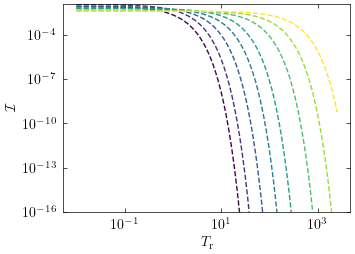

In [239]:
%matplotlib inline
plt.style.use('~/.config/matplotlib/paper.mplstyle')
colors = plt.cm.viridis(np.linspace(0, 1, len(fit_coefficients_dict.keys())))
TR_s = np.logspace(-2,3.4,100)
for L in [4,8,16,32,64,128,256,512]:
    fit_coefficients = fit_coefficients_hybrid_dict[L]
    plt.plot(TR_s, fitted(TR_s, fit_coefficients), label="Fitted function", color=colors[list(fit_coefficients_hybrid_dict.keys()).index(L)], lw=lw, ls='--')
plt.ylim(bottom=1e-16)
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r"$T_\mathrm{r}$")
plt.ylabel(r"$\mathcal I$")
plt.minorticks_off()
plt.savefig("figures/rodeo_fitted_time_cut.pdf", bbox_inches='tight')